In [140]:
!pip install torch torchvision matplotlib

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [141]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        # FIXED: smaller initialization (prevents huge loss)
        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.001)
        self.bias = nn.Parameter(torch.zeros(out_features))

        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features) -2 )

    def forward(self, x):
        # Step 1: soft gates
        gates = torch.sigmoid(self.gate_scores)

        # Step 2: hard threshold
        hard_gates = (gates > 0.1).float()

        # Step 3: straight-through estimator
        gates = hard_gates + gates - gates.detach()

        # Step 4: apply pruning
        pruned_weights = self.weight * gates

        return torch.nn.functional.linear(x, pruned_weights, self.bias)

In [142]:
class PrunableNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.fc1 = PrunableLinear(32*32*3, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [143]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),   # FIXED
                         (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False)

In [144]:
def compute_sparsity_loss(model):
    loss = 0
    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            loss += torch.mean(torch.abs(gates))
    return loss

In [145]:
def train_model(lambda_val):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = PrunableNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(10):
        model.train()
        total_loss = 0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            classification_loss = criterion(outputs, labels)
            sparsity_loss = compute_sparsity_loss(model)

            # FIXED: scaled sparsity term
            loss = classification_loss + lambda_val * sparsity_loss

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss:.3f}")

    return model

In [146]:
def evaluate_model(model):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model.eval()

    correct = 0
    total = 0
    all_gates = []

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    # Collect gate values
    for module in model.modules():
        if isinstance(module, PrunableLinear):
            # FIX: Detach the tensor before converting to numpy
            gates = torch.sigmoid(module.gate_scores).cpu().detach().numpy()
            all_gates.extend(gates.flatten())

    all_gates = np.array(all_gates)

    sparsity = np.mean(all_gates < 1e-2) * 100
    accuracy = 100 * correct / total

    return accuracy, sparsity, all_gates

In [147]:
lambdas = [1,50,10000]

results = []

for lam in lambdas:
    print(f"\nTraining with lambda = {lam}")

    model = train_model(lam)
    acc, sparsity, gates = evaluate_model(model)

    print(f"Accuracy: {acc:.2f}% | Sparsity: {sparsity:.2f}%")

    results.append((lam, acc, sparsity, gates))


Training with lambda = 1
Epoch 1, Loss: 844.318
Epoch 2, Loss: 712.619
Epoch 3, Loss: 645.102
Epoch 4, Loss: 594.974
Epoch 5, Loss: 553.655
Epoch 6, Loss: 517.187
Epoch 7, Loss: 484.558
Epoch 8, Loss: 453.618
Epoch 9, Loss: 426.360
Epoch 10, Loss: 397.495
Accuracy: 54.38% | Sparsity: 21.61%

Training with lambda = 50
Epoch 1, Loss: 8688.316
Epoch 2, Loss: 6639.464
Epoch 3, Loss: 5196.767
Epoch 4, Loss: 4157.609
Epoch 5, Loss: 3400.625
Epoch 6, Loss: 2850.848
Epoch 7, Loss: 2439.593
Epoch 8, Loss: 2119.156
Epoch 9, Loss: 1861.460
Epoch 10, Loss: 1653.761
Accuracy: 48.68% | Sparsity: 44.26%

Training with lambda = 10000
Epoch 1, Loss: 1585641.794
Epoch 2, Loss: 1196505.524
Epoch 3, Loss: 914571.720
Epoch 4, Loss: 708700.593
Epoch 5, Loss: 556692.951
Epoch 6, Loss: 442892.828
Epoch 7, Loss: 356375.606
Epoch 8, Loss: 289592.780
Epoch 9, Loss: 237288.424
Epoch 10, Loss: 195739.484
Accuracy: 10.00% | Sparsity: 45.40%


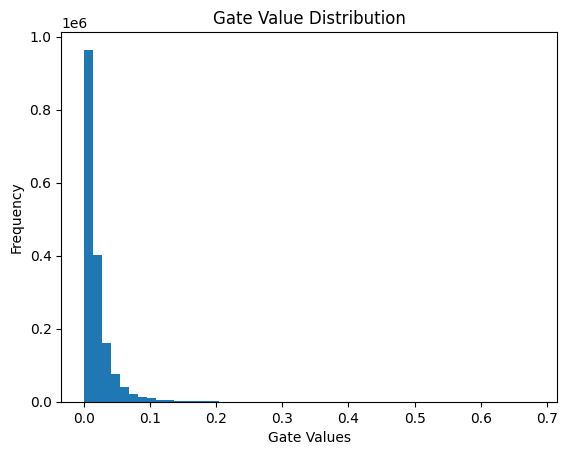

In [148]:
best_model_gates = results[1][3]

plt.hist(best_model_gates, bins=50)
plt.title("Gate Value Distribution")
plt.xlabel("Gate Values")
plt.ylabel("Frequency")
plt.show()